In [2]:
pip install xarray scipy requests

Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import requests
import os, warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

LAT       = 47.40    # Dübendorf
LON       = 8.62
ELEV_ASL  = 448      # m ASL (Dübendorf airport)

DROP_DATE  = '2026-02-06'
DROP_HOUR  = 11       # UTC

OUTPUT_DIR = './figures'
DATA_DIR   =  '/Users/alice/Desktop/Space_Data_2/CanSat data utili'
os.makedirs(OUTPUT_DIR, exist_ok=True)

g = 9.80665
def baro(p, p0): return 44330*(1-(p/p0)**(1/5.255))
def isa_T(h): return 288.15 - 0.0065*h
def isa_p(h): return 1013.25*(isa_T(h)/288.15)**5.255

print('Config OK.')

Config OK.


In [13]:
# ============================================================================
# STEP 1: FETCH ERA5 DATA VIA OPEN-METEO (free, no queue, ~2 sec)
# Docs: https://open-meteo.com/en/docs/historical-weather-api
#
# ERA5 has a ~5-day archive lag. If data is missing, the code automatically
# falls back to ECMWF IFS (available next day) via models=ecmwf_ifs.
# A DEBUG block prints the exact API keys so you can diagnose name issues.
# ============================================================================

era5_ok = False
era5_profiles = {}

# Pressure levels covering 0-1500 m AGL above Dübendorf (448 m ASL)
LEVELS = [975, 950, 925, 900, 875, 850]

def build_vars(levels):
    out = []
    for lev in levels:
        out += [
            f'temperature_{lev}hPa',
            f'relative_humidity_{lev}hPa',
            f'wind_speed_{lev}hPa',          # NOTE: wind_speed not windspeed
            f'geopotential_height_{lev}hPa',
        ]
    return out

def fetch_and_parse(date, hour, model_param=None, label='ERA5'):
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':   LAT,
        'longitude':  LON,
        'start_date': date,
        'end_date':   date,
        'hourly':     ','.join(build_vars(LEVELS)),
        'wind_speed_unit': 'ms',
        'timezone':   'UTC',
    }
    if model_param:
        params['models'] = model_param

    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    # DEBUG: show what keys came back and sample values
    hourly = data.get('hourly', {})
    print(f'  Keys returned: {[k for k in hourly if "temperature" in k]}')
    sample_k = f'temperature_{LEVELS[2]}hPa'
    if sample_k in hourly:
        print(f'  {sample_k} at h11 = {hourly[sample_k][hour] if len(hourly[sample_k]) > hour else "<short list>"}')

    times = hourly.get('time', [])
    target = f'{date}T{hour:02d}:00'
    if target not in times:
        raise ValueError(f'Target time {target} not in response. Available: {times[:5]}...')
    idx_h = times.index(target)

    h_agl_list, T_list, rh_list, ws_list, p_list = [], [], [], [], []
    for lev in LEVELS:
        z  = hourly.get(f'geopotential_height_{lev}hPa', [])
        T  = hourly.get(f'temperature_{lev}hPa', [])
        rh = hourly.get(f'relative_humidity_{lev}hPa', [])
        ws = hourly.get(f'wind_speed_{lev}hPa', [])

        def val(lst): return lst[idx_h] if len(lst) > idx_h else None
        zv, Tv, rhv, wsv = val(z), val(T), val(rh), val(ws)

        if any(v is None for v in [zv, Tv, rhv, wsv]):
            print(f'  Skipping {lev} hPa: z={zv} T={Tv} rh={rhv} ws={wsv}')
            continue
        h_agl_list.append(float(zv) - ELEV_ASL)
        T_list.append(float(Tv))
        rh_list.append(float(rhv))
        ws_list.append(float(wsv))
        p_list.append(float(lev))

    if len(h_agl_list) < 2:
        return None

    order = np.argsort(h_agl_list)
    return {
        'h_agl': np.array(h_agl_list)[order],
        'T':     np.array(T_list)[order],
        'rh':    np.array(rh_list)[order],
        'wspd':  np.array(ws_list)[order],
        'p':     np.array(p_list)[order],
        'time':  times[idx_h],
        'model': label,
    }

# Try ERA5 best-match first, then ECMWF IFS as fallback
for model_param, label in [(None, 'ERA5 (best-match)'), ('ecmwf_ifs', 'ECMWF IFS')]:
    try:
        print(f'\nTrying {label}...')
        prof = fetch_and_parse(DROP_DATE, DROP_HOUR, model_param, label)
        if prof:
            era5_profiles = prof
            era5_ok = True
            print(f'  ✓ {len(prof["h_agl"])} levels: h = {prof["h_agl"].min():.0f}–{prof["h_agl"].max():.0f} m AGL')
            print(f'  T = {prof["T"].min():.1f}–{prof["T"].max():.1f}°C  |  Wind = {prof["wspd"].min():.1f}–{prof["wspd"].max():.1f} m/s')
            break
        else:
            print(f'  → All levels missing, trying fallback...')
    except Exception as e:
        print(f'  ✗ Failed: {e}')

if not era5_ok:
    print('\n⚠ No reanalysis data available — plot will show ISA + Payerne + VAMOS only.')


Trying ERA5 (best-match)...
  Keys returned: ['temperature_975hPa', 'temperature_950hPa', 'temperature_925hPa', 'temperature_900hPa', 'temperature_875hPa', 'temperature_850hPa']
  temperature_925hPa at h11 = None
  Skipping 975 hPa: z=None T=None rh=None ws=None
  Skipping 950 hPa: z=None T=None rh=None ws=None
  Skipping 925 hPa: z=None T=None rh=None ws=None
  Skipping 900 hPa: z=None T=None rh=None ws=None
  Skipping 875 hPa: z=None T=None rh=None ws=None
  Skipping 850 hPa: z=None T=None rh=None ws=None
  → All levels missing, trying fallback...

Trying ECMWF IFS...
  Keys returned: ['temperature_975hPa', 'temperature_950hPa', 'temperature_925hPa', 'temperature_900hPa', 'temperature_875hPa', 'temperature_850hPa']
  temperature_925hPa at h11 = None
  Skipping 975 hPa: z=None T=None rh=None ws=None
  Skipping 950 hPa: z=None T=None rh=None ws=None
  Skipping 925 hPa: z=None T=None rh=None ws=None
  Skipping 900 hPa: z=None T=None rh=None ws=None
  Skipping 875 hPa: z=None T=None rh=

In [14]:
# ============================================================================
# STEP 2: LOAD VAMOS DROP DATA
# ============================================================================

print('Loading VAMOS drop data...')

def clean(df):
    for c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.dropna().reset_index(drop=True)

sv   = clean(pd.read_csv(f'{DATA_DIR}/science_VAMOS.csv'))
t_v  = sv['timestamp_ms'].values / 1000
p_v  = sv['pressure_hPa'].values
T_v  = sv['temperature_C'].values
p0_v = (np.median(p_v[:100]) + np.median(p_v[-500:])) / 2
h_v  = baro(p_v, p0_v)

p_sm = pd.Series(p_v).rolling(5, center=True, min_periods=1).median().values
dpdt = np.gradient(p_sm) / np.gradient(t_v)
idx  = np.where(dpdt > 0.1)[0]
gaps = np.where(np.diff(idx) > 15)[0]
S    = np.concatenate([[idx[0]], idx[gaps+1]]) if len(gaps) else np.array([idx[0]])
E    = np.concatenate([idx[gaps], [idx[-1]]]) if len(gaps) else np.array([idx[-1]])
ib   = np.argmax([p_v[e]-p_v[s] for s,e in zip(S,E)])
ds_v, de_v = S[ib], E[ib]
apex = max(0, ds_v-60) + int(np.argmin(p_v[max(0, ds_v-60):ds_v+1]))
post = np.where(p_v[de_v:min(len(p_v), de_v+60)] > p_v[apex]+30)[0]
land = de_v + (post[0] if len(post) else 0)
ta_v = t_v[apex]; tl_v = t_v[land]
dm_v = (t_v >= ta_v) & (t_v <= tl_v)

T_vd = T_v[dm_v]; h_vd = h_v[dm_v]
print(f'  Drop: {dm_v.sum()} pts, h = {h_vd.min():.0f}–{h_vd.max():.0f} m AGL')

Loading VAMOS drop data...
  Drop: 196 pts, h = 36–713 m AGL


In [15]:
# ============================================================================
# STEP 3: PAYERNE RADIOSONDE (hardcoded)
# ============================================================================

PAY_RAW = """935.9 491 1.9 0.9 93 4 0.3
933.8 509 1.1 1.0 99 45 0.9
930.4 538 0.8 0.7 99 40 1.1
927.8 561 0.6 0.5 100 29 1.2
925.2 584 0.4 0.4 100 19 1.2
922.6 606 0.3 0.3 100 12 1.3
919.1 637 0.1 0.1 100 7 1.3
916.5 660 0.0 0.0 100 9 1.2
914.9 674 -0.0 -0.0 100 12 1.1
912.3 696 -0.2 -0.2 100 23 0.8
909.4 722 -0.3 -0.3 100 50 0.5
905.6 755 -0.5 -0.5 100 123 0.5
902.3 784 -0.7 -0.8 100 151 0.9
900.5 801 -0.2 -2.6 84 159 1.1
898.3 821 1.0 -2.8 76 168 1.3
896.1 840 1.8 -3.4 68 176 1.6
893.3 865 2.5 -2.8 68 185 2.0
890.4 892 3.0 -2.5 67 192 2.6
887.0 923 3.1 -2.5 67 197 3.2
884.1 949 2.9 -2.8 66 201 3.9
881.0 978 2.8 -3.2 65 204 4.4
878.7 998 2.6 -3.8 62 206 4.7
875.0 1032 2.5 -4.1 62 209 5.2
872.5 1056 2.5 -5.2 57 210 5.4
869.2 1087 2.8 -5.6 54 211 5.7
866.9 1108 3.0 -5.1 55 210 5.8
864.5 1130 3.5 -4.0 58 210 5.8
862.3 1151 3.4 -3.3 62 209 5.9
859.8 1175 3.2 -3.2 63 209 6.0
857.6 1196 3.0 -3.1 64 211 6.2
855.5 1215 2.8 -2.6 67 212 6.6
853.2 1237 2.7 -2.5 69 215 7.0
851.0 1258 2.6 -2.5 69 217 7.5
849.3 1274 2.4 -2.4 70 219 7.8
847.1 1295 2.3 -2.1 72 220 8.3
844.8 1317 2.2 -1.9 74 221 8.6
842.6 1338 2.2 -2.0 74 222 8.9
840.4 1359 2.2 -2.3 72 223 9.2
838.1 1382 2.2 -2.4 72 223 9.4
835.9 1403 2.1 -2.4 72 224 9.5
833.7 1424 1.9 -2.5 73 224 9.7
831.5 1445 1.7 -2.5 74 223 9.9
829.2 1467 1.5 -2.5 75 222 10.0
827.0 1489 1.3 -2.5 76 220 10.1
825.9 1499 1.2 -2.5 76 219 10.1"""

_r  = [[float(x) for x in ln.split()] for ln in PAY_RAW.strip().split('\n')]
pay = pd.DataFrame(_r, columns=['p','h_asl','T','Td','rh','wdir','wspd'])
pay['h_agl'] = pay['h_asl'] - ELEV_ASL
wr = np.deg2rad(pay['wdir'])
pay['u'] = -pay['wspd'] * np.sin(wr)
pay['v'] = -pay['wspd'] * np.cos(wr)
print('Payerne data loaded.')

Payerne data loaded.


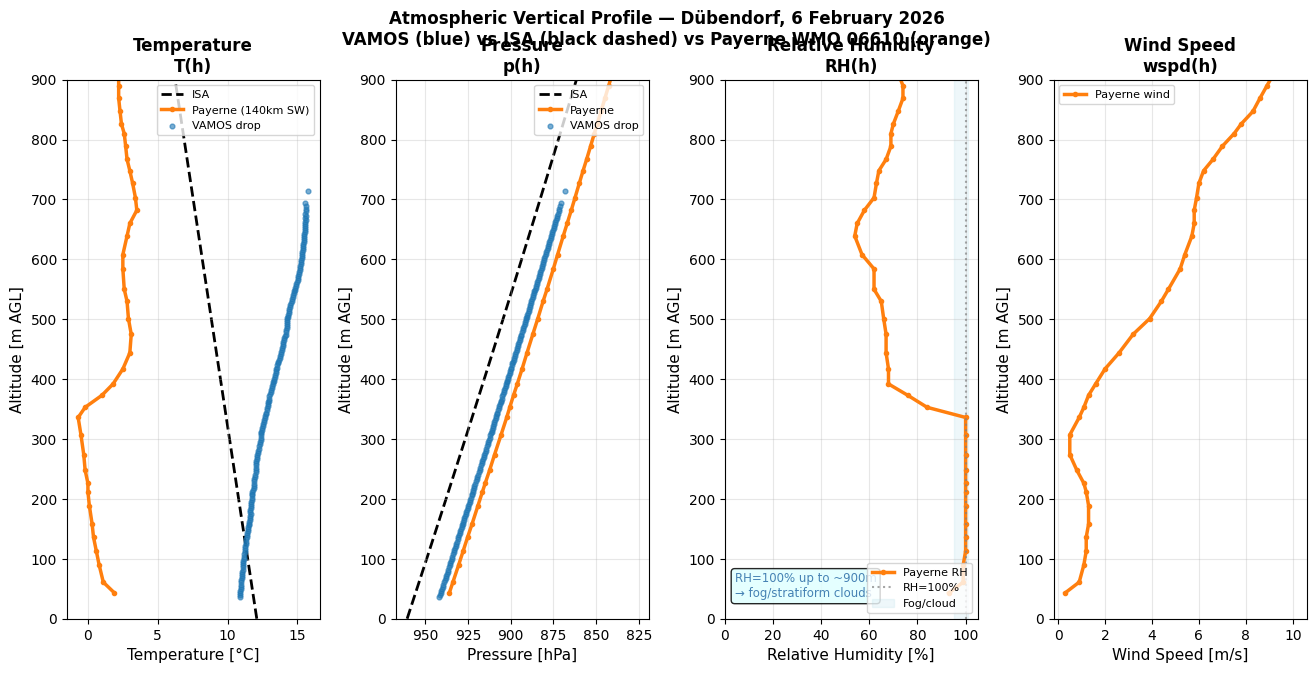

  Saved: ./figures/era5_vertical_profile.png


In [16]:
# ============================================================================
# STEP 4: PLOT
# ============================================================================

C_VAMOS = '#1f77b4'
C_ERA5  = '#e377c2'
C_PAY   = '#ff7f0e'

h_isa_agl = np.linspace(0, 1100, 300)
T_isa_C   = isa_T(h_isa_agl + ELEV_ASL) - 273.15
p_isa     = isa_p(h_isa_agl + ELEV_ASL)

fig = plt.figure(figsize=(16, 7))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.30)
H_LIM = (0, 900)
era5_legend = (f'{era5_profiles["model"]}\n({era5_profiles["time"]}Z)' if era5_ok else '')

ax1 = fig.add_subplot(gs[0])
ax1.plot(T_isa_C, h_isa_agl, 'k--', lw=2, label='ISA', zorder=1)
ax1.plot(pay['T'], pay['h_agl'], color=C_PAY, lw=2.5, marker='o', ms=3, label='Payerne (140km SW)', zorder=2)
if era5_ok:
    ax1.plot(era5_profiles['T'], era5_profiles['h_agl'], color=C_ERA5, lw=2.5, marker='s', ms=6, label=era5_legend, zorder=3)
ax1.scatter(T_vd, h_vd, s=12, c=C_VAMOS, alpha=0.6, label='VAMOS drop', zorder=4)
ax1.set_xlabel('Temperature [°C]', fontsize=11); ax1.set_ylabel('Altitude [m AGL]', fontsize=11)
ax1.set_title('Temperature\nT(h)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right'); ax1.grid(alpha=0.3); ax1.set_ylim(*H_LIM)
if era5_ok:
    bias = np.mean(T_vd) - np.interp(np.mean(h_vd), era5_profiles['h_agl'], era5_profiles['T'])
    ax1.text(0.04, 0.04, f'VAMOS bias vs ERA5:\n{bias:+.1f}°C', transform=ax1.transAxes,
             fontsize=8.5, family='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax2 = fig.add_subplot(gs[1])
ax2.plot(p_isa, h_isa_agl, 'k--', lw=2, label='ISA', zorder=1)
ax2.plot(pay['p'], pay['h_agl'], color=C_PAY, lw=2.5, marker='o', ms=3, label='Payerne', zorder=2)
if era5_ok:
    ax2.plot(era5_profiles['p'], era5_profiles['h_agl'], color=C_ERA5, lw=2.5, marker='s', ms=6, label='ERA5', zorder=3)
ax2.scatter(p_v[dm_v], h_vd, s=12, c=C_VAMOS, alpha=0.6, label='VAMOS drop', zorder=4)
ax2.invert_xaxis()
ax2.set_xlabel('Pressure [hPa]', fontsize=11); ax2.set_ylabel('Altitude [m AGL]', fontsize=11)
ax2.set_title('Pressure\np(h)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right'); ax2.grid(alpha=0.3); ax2.set_ylim(*H_LIM)

ax3 = fig.add_subplot(gs[2])
ax3.plot(pay['rh'], pay['h_agl'], color=C_PAY, lw=2.5, marker='o', ms=3, label='Payerne RH')
if era5_ok:
    ax3.plot(era5_profiles['rh'], era5_profiles['h_agl'], color=C_ERA5, lw=2.5, marker='s', ms=6, label='ERA5 RH')
ax3.axvline(100, color='gray', ls=':', lw=1.5, alpha=0.7, label='RH=100%')
ax3.axvspan(95, 101, color='lightblue', alpha=0.2, label='Fog/cloud')
ax3.set_xlabel('Relative Humidity [%]', fontsize=11); ax3.set_ylabel('Altitude [m AGL]', fontsize=11)
ax3.set_title('Relative Humidity\nRH(h)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, loc='lower right'); ax3.grid(alpha=0.3); ax3.set_ylim(*H_LIM); ax3.set_xlim(0, 105)
ax3.text(0.04, 0.04, 'RH=100% up to ~900m\n→ fog/stratiform clouds',
         transform=ax3.transAxes, fontsize=8.5, color='steelblue',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.85))

ax4 = fig.add_subplot(gs[3])
ax4.plot(pay['wspd'], pay['h_agl'], color=C_PAY, lw=2.5, marker='o', ms=3, label='Payerne wind')
if era5_ok:
    ax4.plot(era5_profiles['wspd'], era5_profiles['h_agl'], color=C_ERA5, lw=2.5, marker='s', ms=6, label='ERA5 wind')
ax4.set_xlabel('Wind Speed [m/s]', fontsize=11); ax4.set_ylabel('Altitude [m AGL]', fontsize=11)
ax4.set_title('Wind Speed\nwspd(h)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, loc='upper left'); ax4.grid(alpha=0.3); ax4.set_ylim(*H_LIM)

fig.suptitle(
    'Atmospheric Vertical Profile — Dübendorf, 6 February 2026\n'
    'VAMOS (blue) vs ISA (black dashed) vs Payerne WMO 06610 (orange)'
    + (f' vs {era5_legend} (pink)' if era5_ok else ''),
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/era5_vertical_profile.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'  Saved: {OUTPUT_DIR}/era5_vertical_profile.png')

In [ ]:
# ============================================================================
# STEP 5: SUMMARY TABLE
# ============================================================================

print('\n' + '='*65)
print('VERTICAL PROFILE SUMMARY')
print('='*65)
print(f'{"Dataset":<20} {"T at 400m":>10} {"p at 400m":>10} {"Source"}')
print('-'*65)

h_ref = 400
T_isa_400   = isa_T(h_ref + ELEV_ASL) - 273.15
p_isa_400   = isa_p(h_ref + ELEV_ASL)
T_vamos_400 = np.interp(h_ref, np.sort(h_vd), T_vd[np.argsort(h_vd)])
T_pay_400   = np.interp(h_ref, pay['h_agl'].values, pay['T'].values)
p_pay_400   = np.interp(h_ref, pay['h_agl'].values, pay['p'].values)

print(f'{"ISA":<20} {T_isa_400:>9.1f}°C {p_isa_400:>9.1f} hPa  theoretical')
print(f'{"VAMOS (measured)":<20} {T_vamos_400:>9.1f}°C {"—":>10}  in-situ CanSat')
print(f'{"Payerne":<20} {T_pay_400:>9.1f}°C {p_pay_400:>9.1f} hPa  radiosonde 140km SW')
if era5_ok:
    T_e = np.interp(h_ref, era5_profiles['h_agl'], era5_profiles['T'])
    p_e = np.interp(h_ref, era5_profiles['h_agl'], era5_profiles['p'])
    print(f'{era5_profiles["model"]:<20} {T_e:>9.1f}°C {p_e:>9.1f} hPa  reanalysis on-site')

print(f'\nVAMOS bias at 400m:')
print(f'  vs ISA:     {T_vamos_400-T_isa_400:+.1f}°C')
print(f'  vs Payerne: {T_vamos_400-T_pay_400:+.1f}°C')
if era5_ok:
    print(f'  vs ERA5:    {T_vamos_400-T_e:+.1f}°C')
print('='*65)